In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
!pip install plotly

In [40]:
import plotly.express as px

In [7]:
df = pd.read_csv("/content/sales_data_sample.csv", encoding="latin1")

In [ ]:
print(df.info())
print(df.describe())
print(df.isnull().sum())

In [17]:
total_sales = df["SALES"].sum()
total_orders = df["ORDERNUMBER"].nunique()
average_order_value = total_sales / total_orders

best_product_line = (
    df.groupby("PRODUCTLINE")["SALES"]
    .sum()
    .sort_values(ascending=False)
)

print("Total Sales:", round(total_sales,2))
print("Total Orders:", total_orders)
print("Average Order Value:", round(average_order_value,2))

print(best_product_line)

Total Sales: 10032628.85
Total Orders: 307
Average Order Value: 32679.57
PRODUCTLINE
Classic Cars        3919615.66
Vintage Cars        1903150.84
Motorcycles         1166388.34
Trucks and Buses    1127789.84
Planes               975003.57
Ships                714437.13
Trains               226243.47
Name: SALES, dtype: float64


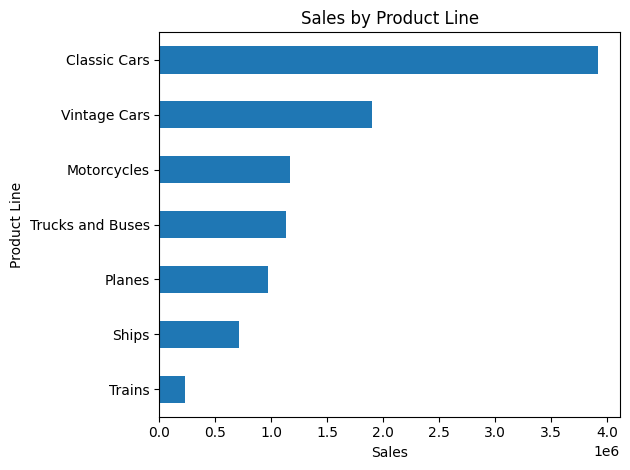

In [14]:
sales_by_product = (
    df.groupby("PRODUCTLINE")["SALES"]
    .sum()
    .sort_values()
)

sales_by_product.plot(kind="barh")

plt.title("Sales by Product Line")
plt.xlabel("Sales")
plt.ylabel("Product Line")

plt.tight_layout()
plt.show()

In [18]:
top_customers = (
    df.groupby("CUSTOMERNAME")["SALES"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

print(top_customers)

CUSTOMERNAME
Euro Shopping Channel           912294.11
Mini Gifts Distributors Ltd.    654858.06
Australian Collectors, Co.      200995.41
Muscle Machine Inc              197736.94
La Rochelle Gifts               180124.90
Dragon Souveniers, Ltd.         172989.68
Land of Toys Inc.               164069.44
The Sharp Gifts Warehouse       160010.27
AV Stores, Co.                  157807.81
Anna's Decorations, Ltd         153996.13
Name: SALES, dtype: float64


In [19]:
df["ORDERDATE"] = pd.to_datetime(df["ORDERDATE"])

df["YEAR_MONTH"] = df["ORDERDATE"].dt.to_period("M")

monthly_sales = (
    df.groupby("YEAR_MONTH")["SALES"]
    .sum()
)

print(monthly_sales)

YEAR_MONTH
2003-01     129753.60
2003-02     140836.19
2003-03     174504.90
2003-04     201609.55
2003-05     192673.11
2003-06     168082.56
2003-07     187731.88
2003-08     197809.30
2003-09     263973.36
2003-10     568290.97
2003-11    1029837.66
2003-12     261876.46
2004-01     316577.42
2004-02     311419.53
2004-03     205733.73
2004-04     206148.12
2004-05     273438.39
2004-06     286674.22
2004-07     327144.09
2004-08     461501.27
2004-09     320750.91
2004-10     552924.25
2004-11    1089048.01
2004-12     372802.66
2005-01     339543.42
2005-02     358186.18
2005-03     374262.76
2005-04     261633.29
2005-05     457861.06
Freq: M, Name: SALES, dtype: float64


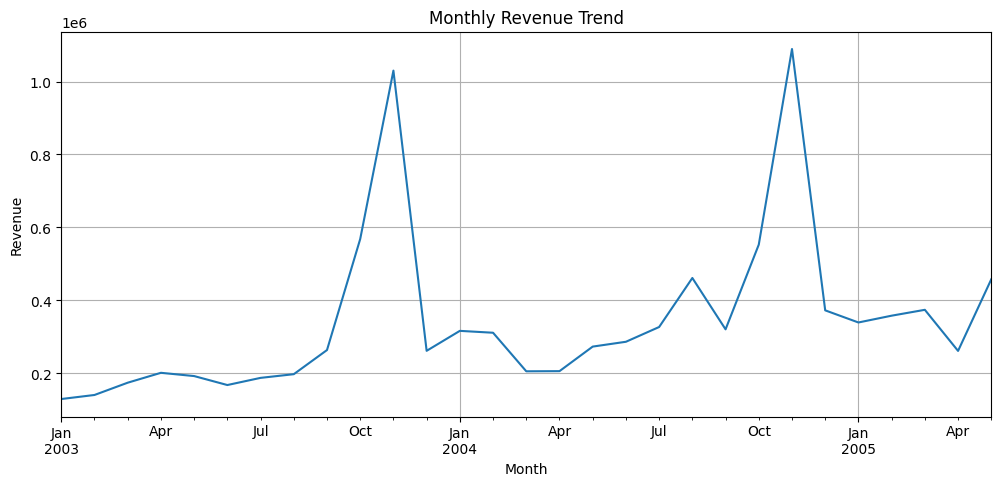

In [20]:
monthly_sales.plot(figsize=(12,5))

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.grid(True)

plt.show()

In [23]:
country_sales = (
    df.groupby("COUNTRY")["SALES"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(country_sales)

COUNTRY
USA          3627982.83
Spain        1215686.92
France       1110916.52
Australia     630623.10
UK            478880.46
Italy         374674.31
Finland       329581.91
Norway        307463.70
Singapore     288488.41
Denmark       245637.15
Name: SALES, dtype: float64


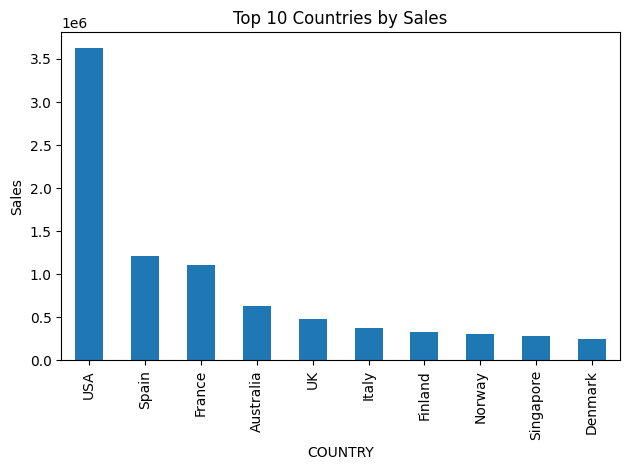

In [22]:
country_sales.plot(kind="bar")

plt.title("Top 10 Countries by Sales")
plt.ylabel("Sales")

plt.tight_layout()
plt.show()

In [24]:
snapshot_date = df["ORDERDATE"].max() + pd.Timedelta(days=1)

rfm = df.groupby("CUSTOMERNAME").agg({
    "ORDERDATE": lambda x: (snapshot_date - x.max()).days,
    "ORDERNUMBER": "nunique",
    "SALES": "sum"
})

rfm.columns = ["Recency", "Frequency", "Monetary"]

print(rfm.head())

                         Recency  Frequency   Monetary
CUSTOMERNAME                                          
AV Stores, Co.               196          3  157807.81
Alpha Cognac                  65          3   70488.44
Amica Models & Co.           265          2   94117.26
Anna's Decorations, Ltd       84          4  153996.13
Atelier graphique            188          3   24179.96


In [25]:
rfm["R_Score"] = pd.qcut(rfm["Recency"], 4, labels=[4,3,2,1])
rfm["F_Score"] = pd.qcut(rfm["Frequency"].rank(method="first"), 4, labels=[1,2,3,4])
rfm["M_Score"] = pd.qcut(rfm["Monetary"], 4, labels=[1,2,3,4])

rfm["RFM_Score"] = (
    rfm["R_Score"].astype(str) +
    rfm["F_Score"].astype(str) +
    rfm["M_Score"].astype(str)
)

print(rfm.head())

                         Recency  Frequency   Monetary R_Score F_Score  \
CUSTOMERNAME                                                             
AV Stores, Co.               196          3  157807.81       2       2   
Alpha Cognac                  65          3   70488.44       4       2   
Amica Models & Co.           265          2   94117.26       1       1   
Anna's Decorations, Ltd       84          4  153996.13       3       4   
Atelier graphique            188          3   24179.96       2       2   

                        M_Score RFM_Score  
CUSTOMERNAME                               
AV Stores, Co.                4       224  
Alpha Cognac                  2       422  
Amica Models & Co.            3       113  
Anna's Decorations, Ltd       4       344  
Atelier graphique             1       221  


In [26]:
top_vip = rfm.sort_values("Monetary", ascending=False)

print(top_vip.head(10))

                              Recency  Frequency   Monetary R_Score F_Score  \
CUSTOMERNAME                                                                  
Euro Shopping Channel               1         26  912294.11       4       4   
Mini Gifts Distributors Ltd.        3         17  654858.06       4       4   
Australian Collectors, Co.        184          5  200995.41       3       4   
Muscle Machine Inc                182          4  197736.94       3       4   
La Rochelle Gifts                   1          4  180124.90       4       4   
Dragon Souveniers, Ltd.            91          5  172989.68       3       4   
Land of Toys Inc.                 198          4  164069.44       2       4   
The Sharp Gifts Warehouse          40          4  160010.27       4       4   
AV Stores, Co.                    196          3  157807.81       2       2   
Anna's Decorations, Ltd            84          4  153996.13       3       4   

                             M_Score RFM_Score  
CU

In [27]:
def segment_customer(row):
    if row["Monetary"] > rfm["Monetary"].quantile(0.75):
        return "VIP"

    elif row["Frequency"] > rfm["Frequency"].median():
        return "Loyal"

    else:
        return "Regular"

rfm["Segment"] = rfm.apply(segment_customer, axis=1)

print(rfm["Segment"].value_counts())

Segment
Regular    63
VIP        23
Loyal       6
Name: count, dtype: int64


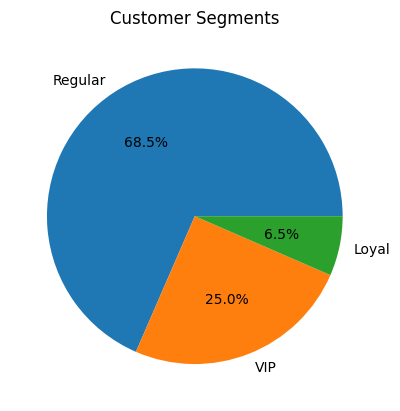

In [28]:
rfm["Segment"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Customer Segments")
plt.ylabel("")
plt.show()

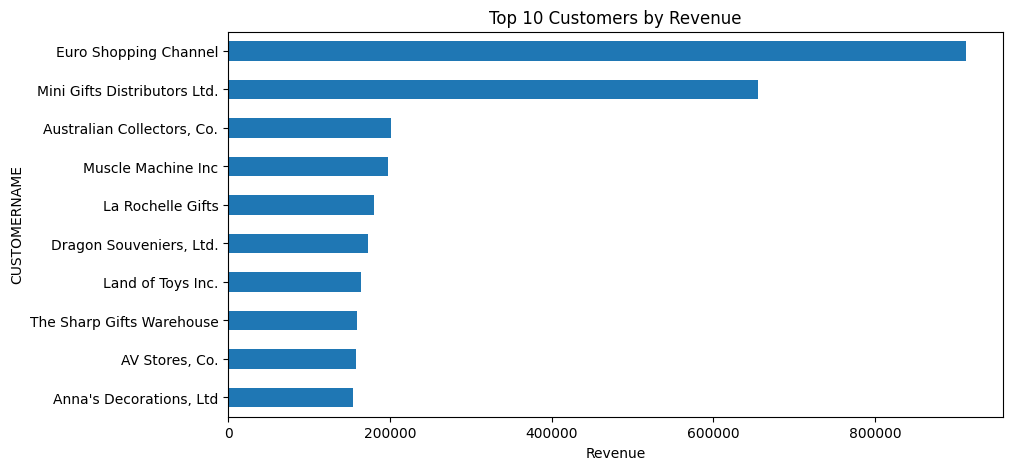

In [29]:
top10 = rfm.sort_values(
    "Monetary",
    ascending=False
).head(10)

top10["Monetary"].sort_values().plot(
    kind="barh",
    figsize=(10,5)
)

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Revenue")

plt.show()

In [30]:
top_products = (
    df.groupby("PRODUCTCODE")["SALES"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_products)

PRODUCTCODE
S18_3232    288245.42
S10_1949    191073.03
S10_4698    170401.07
S12_1108    168585.32
S18_2238    154623.95
S12_3891    145332.04
S24_3856    140626.90
S12_2823    140006.16
S18_1662    139421.97
S12_1099    137177.01
Name: SALES, dtype: float64


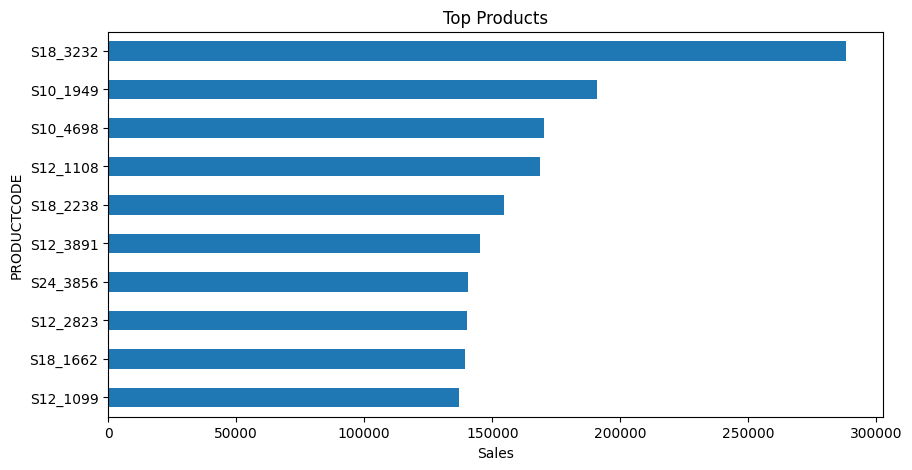

In [31]:
top_products.sort_values().plot(
    kind="barh",
    figsize=(10,5)
)

plt.title("Top Products")
plt.xlabel("Sales")

plt.show()

In [32]:
customer_sales = (
    df.groupby("CUSTOMERNAME")["SALES"]
    .sum()
    .sort_values(ascending=False)
)

pareto = customer_sales.reset_index()

pareto["Cumulative_Sales"] = pareto["SALES"].cumsum()

pareto["Cumulative_Percentage"] = (
    pareto["Cumulative_Sales"]
    / pareto["SALES"].sum()
    * 100
)

print(
    pareto[
        pareto["Cumulative_Percentage"] <= 80
    ]
)

                    CUSTOMERNAME      SALES  Cumulative_Sales  \
0          Euro Shopping Channel  912294.11         912294.11   
1   Mini Gifts Distributors Ltd.  654858.06        1567152.17   
2     Australian Collectors, Co.  200995.41        1768147.58   
3             Muscle Machine Inc  197736.94        1965884.52   
4              La Rochelle Gifts  180124.90        2146009.42   
5        Dragon Souveniers, Ltd.  172989.68        2318999.10   
6              Land of Toys Inc.  164069.44        2483068.54   
7      The Sharp Gifts Warehouse  160010.27        2643078.81   
8                 AV Stores, Co.  157807.81        2800886.62   
9        Anna's Decorations, Ltd  153996.13        2954882.75   
10     Souveniers And Things Co.  151570.98        3106453.73   
11      Corporate Gift Ideas Co.  149882.50        3256336.23   
12         Salzburg Collectables  149798.63        3406134.86   
13      Danish Wholesale Imports  145041.60        3551176.46   
14        Saveley & Henri

In [33]:
customers_needed = len(
    pareto[
        pareto["Cumulative_Percentage"] <= 80
    ]
)

total_customers = len(pareto)

print(
    f"{customers_needed} customers generate 80% of revenue"
)

print(
    f"{customers_needed/total_customers*100:.2f}% of customers"
)

56 customers generate 80% of revenue
60.87% of customers


In [42]:
country_sales = (
    df.groupby("COUNTRY")["SALES"]
    .sum()
    .reset_index()
)

fig = px.bar(
    country_sales,
    x="COUNTRY",
    y="SALES",
    title="Sales by Country"
)

fig.show()

# Sales Analysis Project

## Project Overview

This project analyzes a retail sales dataset to uncover revenue drivers, customer behavior patterns, top-performing products, and business growth opportunities.

The analysis includes data cleaning, exploratory data analysis (EDA), customer segmentation using RFM analysis, and Pareto analysis to identify the customers contributing the most revenue.

---

## Business Problem

The company wants to answer the following questions:

- Which products generate the most revenue?
- Which countries contribute the highest sales?
- Who are the most valuable customers?
- How are sales changing over time?
- Does a small group of customers generate most of the revenue?
- How can the company increase revenue and customer retention?

---

## Dataset Information

- Total Transactions: 2,823
- Total Customers: 92
- Total Orders: 307
- Product Categories: 7
- Countries: Multiple international markets

---

## Tools & Libraries

- Python
- Pandas
- NumPy
- Matplotlib
- Plotly

---

## Data Cleaning

The following preprocessing steps were performed:

- Checked for missing values
- Converted date columns to datetime format
- Removed unnecessary fields
- Verified data types
- Created new date-based features

---

## Key Performance Indicators (KPIs)

| Metric | Value |
|----------|----------|
| Total Revenue | $10,032,628.85 |
| Total Orders | 307 |
| Average Order Value | $32,679.57 |
| Total Customers | 92 |

---

## Product Analysis

### Top Product Lines

| Product Line | Revenue |
|-------------|-------------|
| Classic Cars | $3.92M |
| Vintage Cars | $1.90M |
| Motorcycles | $1.17M |
| Trucks and Buses | $1.13M |
| Planes | $0.98M |

### Key Insight

Classic Cars generated approximately 39% of total company revenue and represented the strongest product category.

---

## Customer Analysis

### Top Customers

| Customer | Revenue |
|-----------|-----------|
| Euro Shopping Channel | $912K |
| Mini Gifts Distributors Ltd. | $655K |
| Australian Collectors, Co. | $201K |
| Muscle Machine Inc | $198K |
| La Rochelle Gifts | $180K |

### Key Insight

A relatively small group of customers generated a significant portion of total revenue.

---

## Sales Trend Analysis

Monthly sales trends showed strong seasonality.

### Key Findings

- November 2004 achieved the highest revenue.
- November was the strongest month across multiple years.
- Sales increased significantly during Q4.
- October and November consistently outperformed other months.

---

## Country Analysis

### Top Countries by Revenue

| Country | Revenue |
|----------|----------|
| USA | $3.63M |
| Spain | $1.22M |
| France | $1.11M |
| Australia | $631K |
| UK | $479K |

### Key Insight

The United States was the largest market and contributed more than one-third of total revenue.

---

## RFM Customer Segmentation

Customers were segmented using:

- Recency
- Frequency
- Monetary Value

### Segment Distribution

| Segment | Customers |
|----------|----------|
| Regular | 63 |
| VIP | 23 |
| Loyal | 6 |

### Key Insight

VIP customers represent a small portion of the customer base but contribute significantly to overall revenue.

---

## Pareto Analysis

The 80/20 rule was tested to determine customer revenue concentration.

### Results

- 56 customers generated 80% of total revenue.
- These customers represented 60.87% of the customer base.

### Key Insight

Revenue was distributed across a broad customer base rather than being concentrated among a small number of customers.

---

## Business Recommendations

### Customer Strategy

- Retain VIP customers through loyalty programs.
- Increase engagement with Regular customers.
- Develop personalized marketing campaigns.

### Product Strategy

- Increase inventory for Classic Cars.
- Prioritize top-performing products.
- Monitor underperforming product categories.

### Sales Strategy

- Prepare promotional campaigns before Q4.
- Focus expansion efforts on USA, Spain, and France.
- Invest in customer retention initiatives.

